# Credit Card Fraud Detection

## Objective

The aim of this project is to build a machine learning pipeline capable of detecting fraudulent credit card transactions.

Three separate datasets containing transaction, customer and terminal information were merged during the data cleaning process before new behavioural features were engineered.

Several machine learning classification models were trained and evaluated to determine which model best detects fraudulent transactions.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/feature_engineered_transactions.csv")

df.head()

,transaction_id,post_ts,customer_id,bin,terminal_id,amt,entry_mode,fraud,mean_amount,std_amount,mean_nb_tx_per_day,network_id,lat_customer,log_customer,available_terminals,nb_terminals,lat_terminal,log_terminal,mcc,hour,day_of_week,is_weekend,night_transaction,amount_difference,amount_ratio,amount_zscore,minutes_since_last_transaction,terminal_changed,rapid_terminal_change,distance_between_customer_and_terminal
0,2UaIjzJfQ5Gnq8oIK8gbPg,2023-02-01 09:37:38,C00001000,375601,T001088,100.98,Swipe,0,73.322301,36.661151,1.596367,A,39.1764,7.4727,"['T001057', 'T001055', 'T001088']",3,39.0467,7.9477,5812,9,2,0,0,27.657699,1.377207,0.754414,-1.000000,0,0,0.492389
1,MhBei11RSpiWLrshq3eGKg,2023-02-01 10:01:34,C00001000,375601,T001088,118.92,Contactless,0,73.322301,36.661151,1.596367,A,39.1764,7.4727,"['T001057', 'T001055', 'T001088']",3,39.0467,7.9477,5812,10,2,0,0,45.597699,1.621880,1.243761,23.933333,0,0,0.492389
2,sN7_g26gTHKn8Wb6tx6GkA,2023-02-01 19:24:48,C00001000,375601,T001055,66.78,Contactless,0,73.322301,36.661151,1.596367,A,39.1764,7.4727,"['T001057', 'T001055', 'T001088']",3,38.9113,7.8866,5813,19,2,0,0,-6.542301,0.910773,-0.178453,563.233333,1,0,0.491519
3,mOjq9X2vSrqAP4eySRvpYw,2023-02-01 19:31:25,C00001000,375601,T001088,53.14,Chip,0,73.322301,36.661151,1.596367,A,39.1764,7.4727,"['T001057', 'T001055', 'T001088']",3,39.0467,7.9477,5812,19,2,0,0,-20.182301,0.724745,-0.550509,6.616667,1,0,0.492389
4,6wkSdMJsTqe9cAVWYkqZpQ,2023-02-02 11:21:38,C00001000,375601,T001088,33.81,Swipe,0,73.322301,36.661151,1.596367,A,39.1764,7.4727,"['T001057', 'T001055', 'T001088']",3,39.0467,7.9477,5812,11,3,0,0,-39.512301,0.461115,-1.077770,950.216667,0,0,0.492389


## Dataset Overview

Before building the machine learning model I explored the data itself.

This includes:

- Number of observations
- Number of features
- Data types
- Overall summary statistics

In [21]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1785308 entries, 0 to 1785307
Data columns (total 30 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   transaction_id                          str    
 1   post_ts                                 str    
 2   customer_id                             str    
 3   bin                                     int64  
 4   terminal_id                             str    
 5   amt                                     float64
 6   entry_mode                              str    
 7   fraud                                   int64  
 8   mean_amount                             float64
 9   std_amount                              float64
 10  mean_nb_tx_per_day                      float64
 11  network_id                              str    
 12  lat_customer                            float64
 13  log_customer                            float64
 14  available_terminals                     str  

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bin,1785308.0,425473.371399,65675.060170,360038.000000,367016.000000,403642.000000,510024.000000,557888.000000
amt,1785308.0,55.029437,41.216166,0.000000,21.960000,46.070000,79.190000,304.600000
fraud,1785308.0,0.030005,0.170602,0.000000,0.000000,0.000000,0.000000,1.000000
mean_amount,1785308.0,52.848760,27.738277,5.014691,28.662413,52.699588,77.882068,99.999956
std_amount,1785308.0,26.424380,13.869138,2.507345,14.331206,26.349794,38.941034,49.999978
mean_nb_tx_per_day,1785308.0,2.671549,0.940562,0.002007,2.009089,2.831038,3.471842,3.999182
lat_customer,1785308.0,39.584712,1.488761,37.000800,38.277800,39.557800,40.890700,42.147500
log_customer,1785308.0,8.451645,0.602843,7.400900,7.923800,8.465100,8.962400,9.499800
nb_terminals,1785308.0,6.165367,2.454307,1.000000,5.000000,6.000000,8.000000,15.000000
lat_terminal,1785308.0,39.606201,1.434814,37.218000,38.221700,39.492200,40.826600,41.958800


## Missing Values

Missing values can negatively impact machine learning models.

I checked the dataset to ensure that all missing values have been handled during the cleaning process.

In [23]:
#The cleaned dataset contained no missing values after being processed.
df.isna().sum()

transaction_id                            0
post_ts                                   0
customer_id                               0
bin                                       0
terminal_id                               0
amt                                       0
entry_mode                                0
fraud                                     0
mean_amount                               0
std_amount                                0
mean_nb_tx_per_day                        0
network_id                                0
lat_customer                              0
log_customer                              0
available_terminals                       0
nb_terminals                              0
lat_terminal                              0
log_terminal                              0
mcc                                       0
hour                                      0
day_of_week                               0
is_weekend                                0
night_transaction               

## Class Distribution

Fraud detection is an imbalanced classification problem there is not a lot of fraud for every transaction.

Understanding the proportion of fraudulent and legitimate transactions is important because accuracy alone can be misleading.

In [39]:
fraud_counts = df["fraud"].value_counts()
fraud_percent = df["fraud"].value_counts(normalize=True) * 100

fraud_counts, fraud_percent

(fraud
 0    1731739
 1      53569
 Name: count, dtype: int64,
 fraud
 0    96.999453
 1     3.000547
 Name: proportion, dtype: float64)

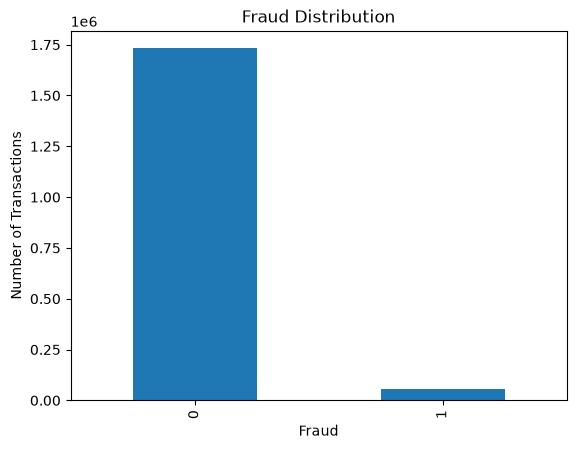

In [40]:
fraud_counts.plot(kind="bar")

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")

plt.show()

The dataset is highly imbalanced with significantly less fraudulent transactions than legitimate ones.

This justified the use of `class_weight="balanced"` in the Logistic Regression and Random Forest models.

## Transaction Amount Analysis

The transaction amount is one of the most important features available.

The following visualisations investigate its overall distribution and whether fraudulent transactions are affected by larger amounts / hour of the day / distance of the customer from the terminal 

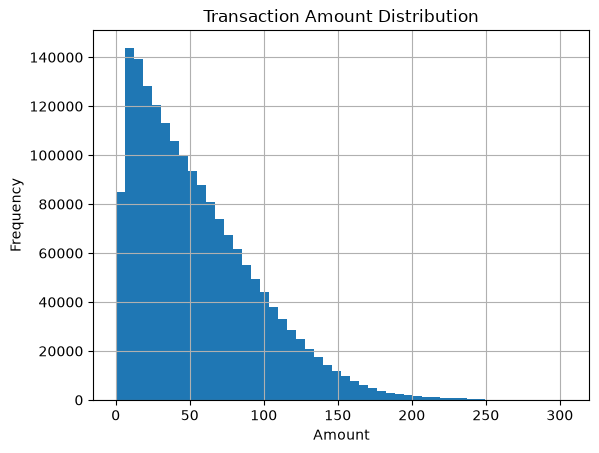

In [ ]:
df["amt"].hist(bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

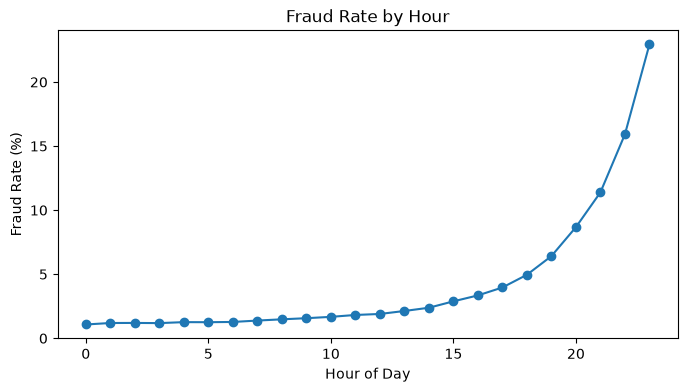

In [33]:
fraud_by_hour = (
    df.groupby("hour")["fraud"]
      .mean()
      * 100
)

plt.figure(figsize=(8,4))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour")

plt.show()

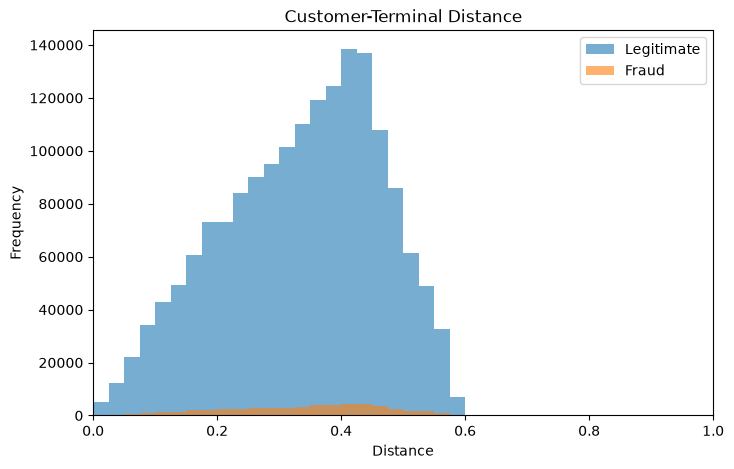

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["fraud"] == 0]["distance_between_customer_and_terminal"],
    bins=40,
    alpha=0.6,
    range=(0, 1),
    label="Legitimate"
)

plt.hist(
    df[df["fraud"] == 1]["distance_between_customer_and_terminal"],
    bins=40,
    alpha=0.6,
    range=(0, 1),
    label="Fraud"
)

plt.xlim(0, 1)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Customer-Terminal Distance")
plt.legend()

plt.show()

## Feature Engineering

Additional behavioural features were created to provide more information to the machine learning models.

| Feature | Reason |
|---------|--------|
| hour | Fraud may occur at unusual times |
| day_of_week | Fraud patterns may differ throughout the week |
| distance_customer_terminal | Fraudsters often use terminals further from the customer's normal location |
| time_since_last_transaction | Rapid transactions may indicate suspicious behaviour |
| rapid_terminal_change | Potential impossible travel |


## Correlation Analysis

Correlation analysis allows us to investigate linear relationships between numerical variables.

While tree-based models do not require highly correlated features, correlation can still provide useful insights.

In [26]:
corr = df.corr(numeric_only=True)

corr["fraud"].sort_values(ascending=False)

fraud                                     1.000000
amount_ratio                              0.166326
amount_zscore                             0.166326
amount_difference                         0.146697
hour                                      0.135890
amt                                       0.104737
mean_nb_tx_per_day                        0.023741
night_transaction                         0.014976
bin                                       0.001500
mcc                                       0.001257
lat_terminal                              0.000195
lat_customer                              0.000119
nb_terminals                              0.000018
mean_amount                              -0.000034
std_amount                               -0.000034
distance_between_customer_and_terminal   -0.000206
day_of_week                              -0.000463
is_weekend                               -0.000647
log_customer                             -0.001407
log_terminal                   

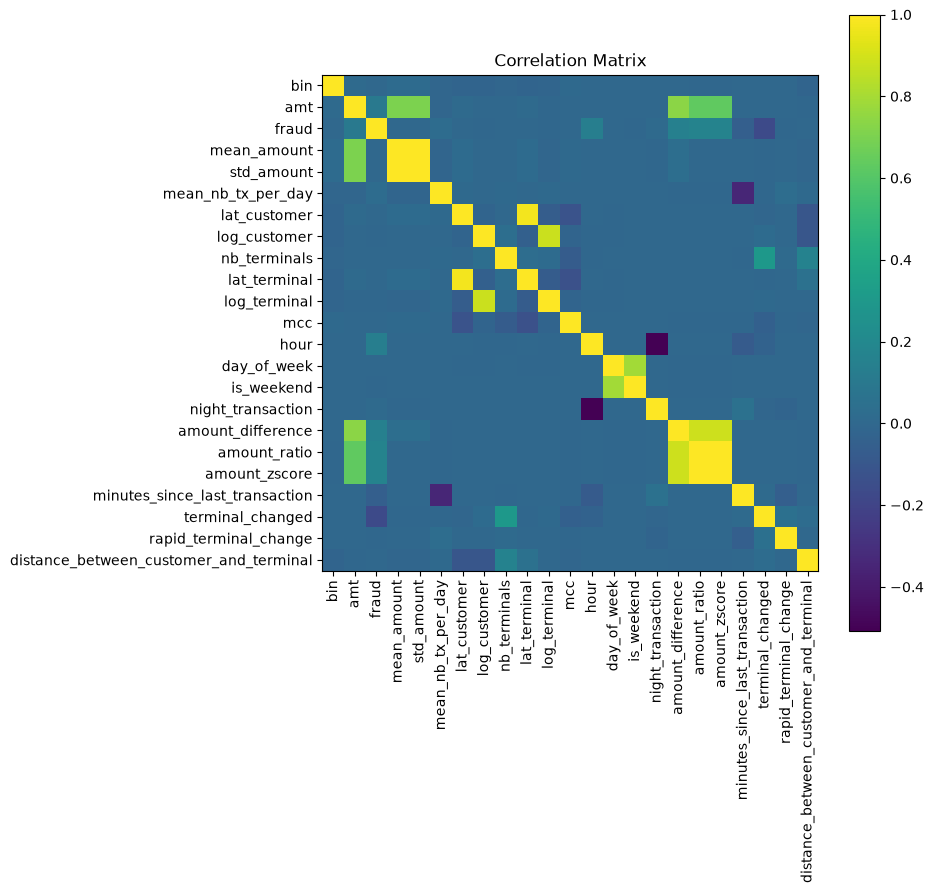

In [27]:
plt.figure(figsize=(8,8))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

The correlation matrix shows that no individual feature has a particularly strong linear correlation with the fraud label.

This suggests that fraudulent behaviour cannot be identified using a single variable alone. The machine learning models are able to combine many weak signals to distinguish fraudulent transactions from legitimate ones.

This is one of the reasons why ensemble methods such as Gradient Boosting performed well in this project.

## Machine Learning Results

Three classification models were trained and evaluated.

The primary evaluation metric used was ROC-AUC because it is well suited to highly imbalanced classification problems.

In [28]:
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting (Tuned)"

    ],

    "ROC-AUC": [

        0.8965,
        0.9603,
        0.9662,
        0.9662

    ]

})

results

,Model,ROC-AUC
0,Logistic Regression,0.8965
1,Random Forest,0.9603
2,Gradient Boosting,0.9662
3,Gradient Boosting (Tuned),0.9662


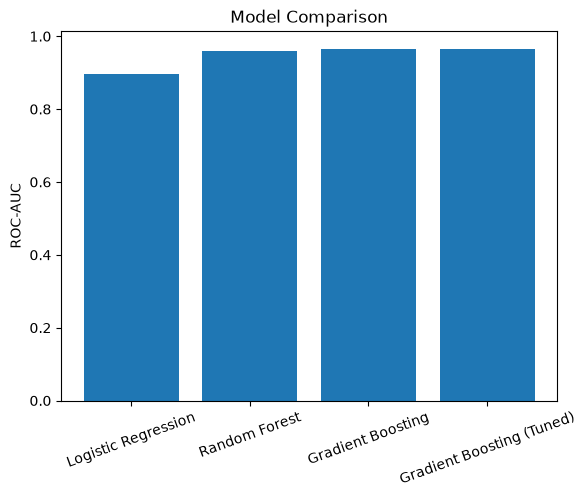

In [29]:
plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.xticks(rotation=20)

plt.ylabel("ROC-AUC")

plt.title("Model Comparison")

plt.show()

The Gradient Boosting classifier achieved the highest ROC-AUC score and therefore became the recommended model.

Hyperparameter tuning produced only a small improvement, indicating that the default model already performed very well on this dataset.

# Conclusion

This project successfully developed an end-to-end machine learning pipeline for detecting fraudulent credit card transactions.

The pipeline included:

- Extracting and combining multiple datasets
- Feature engineering
- Data preprocessing
- Model training
- Model evaluation
- Hyperparameter tuning

Among the models tested, the tuned Gradient Boosting classifier achieved the strongest overall performance with a ROC-AUC score of approximately **0.966**, demonstrating excellent ability to distinguish fraudulent transactions from legitimate ones.